In [85]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import numpy as np
import matplotlib.pyplot as plt

In [86]:
sim = Simulation("FieldDistortion")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

In [87]:
output = sim.run(removeOutputFile = True)
xDistorted, yDistorted = (output.getStarCoordinates(0)[3:5])
rDistorted = np.sqrt(xDistorted**2 + yDistorted**2)

In [88]:
sim["Camera/IncludeFieldDistortion"] = "yes"
output = sim.run(removeOutputFile = True)
xUndistorted, yUndistorted = (output.getStarCoordinates(0)[3:5])
rUndistorted = np.sqrt(xUndistorted**2 + yUndistorted**2)

# Position angle

In [89]:
angleDistorted = np.rad2deg(np.arctan2(yDistorted, xDistorted))
angleUndistorted = np.rad2deg(np.arctan2(yUndistorted, xUndistorted))

(0, 180)

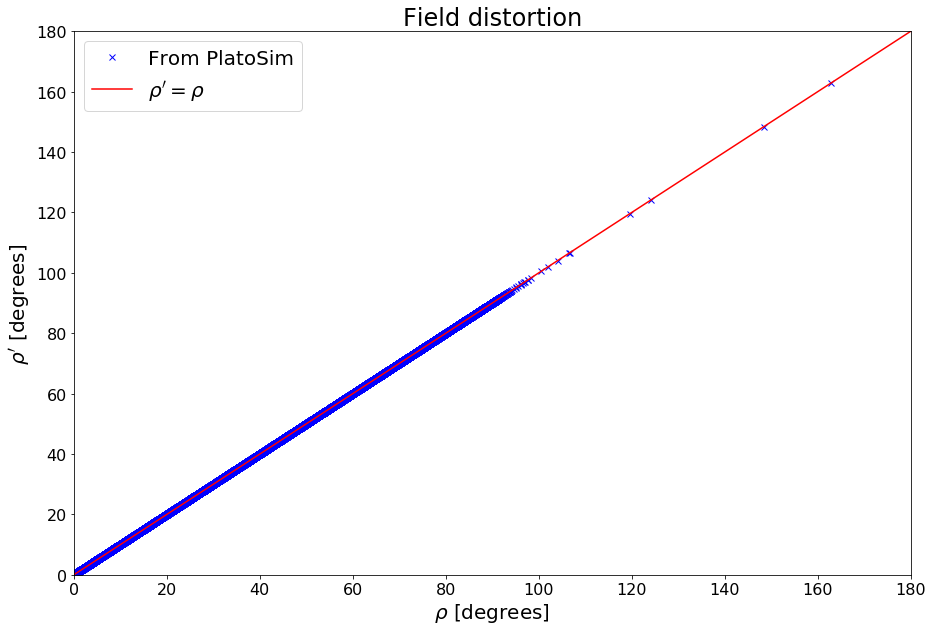

In [93]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(angleDistorted, angleUndistorted, "bx", label = "From PlatoSim")



########
# 𝞀' = 𝞀
########

plt.plot([0,180], [0,180], "r", label = "$\\rho' = \\rho$")




########
# Layout
########

plt.title("Field distortion", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$\\rho$ [degrees]", fontsize = 20)
plt.ylabel("$\\rho'$ [degrees]", fontsize = 20)

plt.xlim([0,180])
plt.ylim([0,180])

# $\Delta r_{FP} = r'_{FP} - r_{FP}$

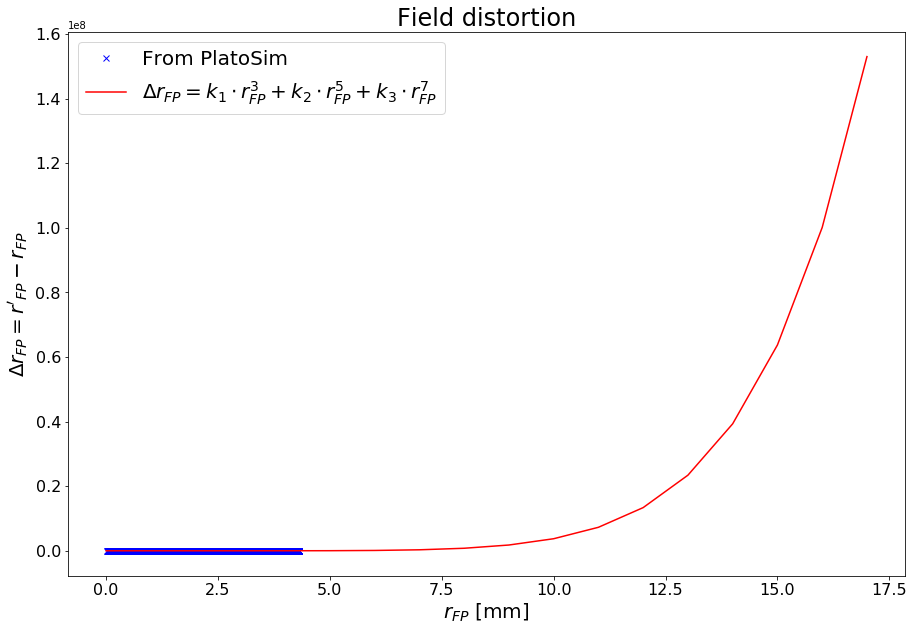

In [92]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(rUndistorted, rDistorted - rUndistorted, "bx", label = "From PlatoSim")




####################################################
# ∆r_FP  = [k_1∙ r_FP^3+ k_2∙ r_FP^5  + k_3∙ r_FP^7]
####################################################

k1, k2, k3 = sim["Camera/FieldDistortion/ConstantCoefficients"]

r = np.arange(0, 18)
rel = k1 * r**3 + k2 * r**5 + k3 * r**7

plt.plot(r, rel, "r", label = "$\Delta r_{FP} = k_1 \cdot r_{FP}^3 + k_2 \cdot r_{FP}^5 + k_3 \cdot r_{FP}^7$")


########
# Layout
########

plt.xlabel("$r_{FP}$ [mm]", fontsize = 20)
plt.ylabel("$\Delta r_{FP} = r'_{FP} - r_{FP}$", fontsize = 20)

plt.title("Field distortion", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)


# $\Delta r'_{FP} = r_{FP} - r'_{FP}$

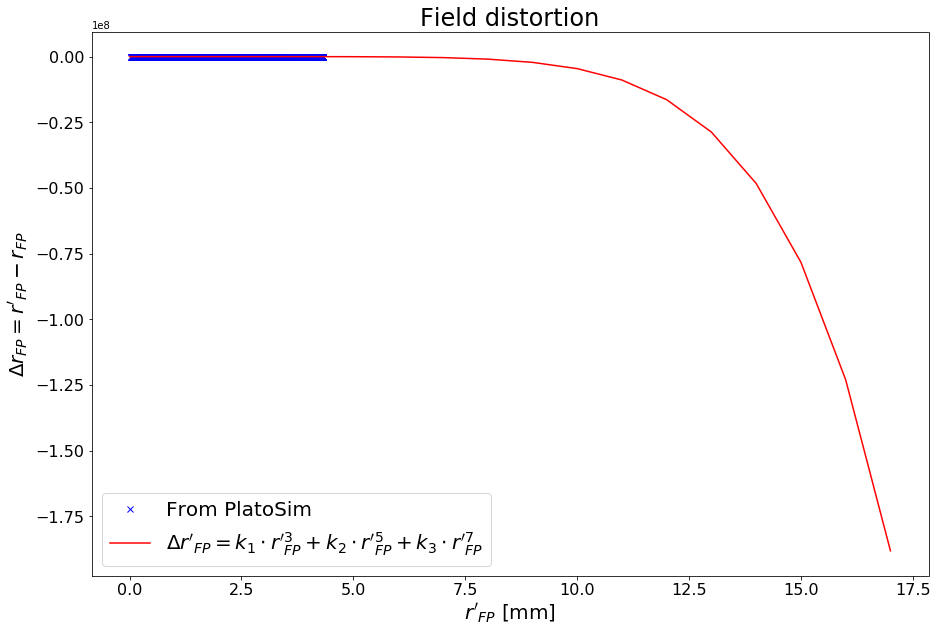

In [94]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(rDistorted, rUndistorted - rDistorted, "bx", label = "From PlatoSim")




########################################################
# ∆r'_FP  = [k_1∙ r'_FP^3+ k_2∙ r'_FP^5  + k_3∙ r'_FP^7]
########################################################

k1, k2, k3 = sim["Camera/FieldDistortion/ConstantInverseCoefficients"]

r = np.arange(0, 18)
rel = k1 * r**3 + k2 * r**5 + k3 * r**7

plt.plot(r, rel, "r", label = "$\Delta r'_{FP} = k_1 \cdot r'_{FP}^3 + k_2 \cdot r'_{FP}^5 + k_3 \cdot r'_{FP}^7$")



########
# Layout
########

plt.xlabel("$r'_{FP}$ [mm]", fontsize = 20)
plt.ylabel("$\Delta r_{FP} = r'_{FP} - r_{FP}$", fontsize = 20)

plt.title("Field distortion", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)